# Solution [OPTIONAL]: Identify land use from aerial images using Convolutional Neural Networks - Part 2

## Improve Performance with Data Augmentation


In this notebook, we will use data augmentation and directly compare our results to the solution in part 1. At first, we will use only a subset of our data, and try to approach the accuracy achieved in part 1 using less data but with data augmentation. Later, we will run it on the full dataset to improve our model and see what is the best performance we can achieve.

## Setup

In [ ]:
# Import modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
import os

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import transforms
from torchsummary import summary

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
folder_path = '/content/drive/MyDrive/Colab Notebooks/data'  # Example path
%cd "$folder_path"

Mounted at /content/drive
/content/drive/.shortcut-targets-by-id/1boy-gFID3nvWPeLsN4uWeEvAbDL-xlNV/data


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Starting small
First, we will start by only loading in a small subset of the data with only 500 images, 350 of which will be used for training. Our goal will be to see if we can push the limits of this subset to approach the accuracy we reached in part 1 with data augmentation.

In [ ]:
# Loading only a subset of the data
sample_size = 500
df = pd.read_csv('labels.csv').sample(sample_size, random_state=42)

# Get image file paths and labels
image_paths = df['image'].values
labels = df['label'].values
num_classes = 21 # We specify the max number of classes in the dataset, regardless of the initial subsampling
print(f'Loaded {len(image_paths)} images, with {num_classes} different classes.')

# Load the mapping between integer labels and class names
label_mapping = {}
with open('label_mapping.txt', 'r') as file:
    for line in file:
        value, key = line.strip().split(': ')
        label_mapping[int(key)] = value

Loaded 500 images, with 21 different classes.


In [ ]:
# Split the data with the same random seed as in part 1 (42) so that we can directly compare
train_paths, test_paths, original_train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.30, random_state=42)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_paths, test_labels, test_size=0.5, random_state=42)

### Load the original train dataset

In [ ]:
def load_images(file_paths, transform, folder_path='Images/'):
    images = []
    for file_path in tqdm(file_paths, desc='Loading images'):
        with Image.open(folder_path+file_path) as img:
            img = img.convert('RGB')
            img = transform(img)
            images.append(img)
    return torch.stack(images)

def calculate_mean_std(stacked_images):
    # Mean and std are calculated across the height and width dimensions (2 and 3)
    mean = stacked_images.view(stacked_images.size(0), stacked_images.size(1), -1).mean(dim=2).mean(dim=0)
    std = stacked_images.view(stacked_images.size(0), stacked_images.size(1), -1).std(dim=2).mean(dim=0)
    return mean, std

# Basic image transformations to load the training dataset
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# mean/std calculation
original_train_images = load_images(train_paths, basic_transform)
mean, std = calculate_mean_std(original_train_images)
normalize_transform = transforms.Normalize(mean=mean, std=std)
original_train_images = torch.stack([normalize_transform(image) for image in original_train_images])

# Transformation with normalization for validation and test dataset
transform = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),        # 224x224 is a common "historical" format for benchmarking CNNs
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load and normalize the validation and test datasets
val_images = load_images(val_paths, transform)
test_images = load_images(test_paths, transform)

# Convert labels to tensors
train_labels = torch.tensor(original_train_labels)
val_labels = torch.tensor(val_labels)
test_labels = torch.tensor(test_labels)

# Create TensorDatasets
train_dataset = TensorDataset(original_train_images, train_labels)
val_dataset = TensorDataset(val_images, val_labels)
test_dataset = TensorDataset(test_images, test_labels)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Loading images: 100%|██████████| 75/75 [01:04<00:00,  1.16it/s]


### No Data Augmentation
For the sake of comparison, lets first run the model with the subset data and no data augmentation to later compare.

In [ ]:
# Model from part 1
class EvenDeeperCNN(nn.Module):
    def __init__(self, num_classes):
        super(EvenDeeperCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.conv5 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.conv6 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.conv7 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.conv8 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.conv9 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.conv10 = nn.Conv2d(512, 512, kernel_size=3, padding=1)

        # Pooling layers
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # MLP classifier
        self.fc = nn.Linear(512 * 7 * 7, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool(x)

        x = F.relu(self.conv5(x))
        x = F.relu(self.conv6(x))
        x = self.pool(x)

        x = F.relu(self.conv7(x))
        x = F.relu(self.conv8(x))
        x = self.pool(x)

        x = F.relu(self.conv9(x))
        x = F.relu(self.conv10(x))
        x = self.pool(x)

        x = x.view(-1, 512 * 7 * 7)  # Flatten the tensor

        x = self.fc(x)

        return x

In [ ]:
criterion = nn.CrossEntropyLoss()
def train(model, train_loader, path = '/best_model.pth', lr=0.005, num_epochs=5):
  # Define loss function, optimizer and training epochs
  optimizer = optim.AdamW(model.parameters(), lr=lr)


  # Initialize the metrics
  metrics = {'training losses' : [],
             'validation losses' : [],
             'validation accuracies' : [],
             'validation precisions' : [],
             'validation recalls' : [],
             'validation f1 scores' : []}


  # We keep track of the best validation accuracy and save the best model
  best_val_accuracy = 0.0

  # Training loop
  for epoch in range(num_epochs):
      model.train()
      training_loss = 0.0
      for images, labels in train_loader:
          images, labels = images.to(device), labels.to(device)
          optimizer.zero_grad()
          outputs = model(images)
          loss = criterion(outputs, labels)
          loss.backward()
          optimizer.step()
          training_loss += loss.item()

      # Store average training loss for the epoch
      metrics['training losses'].append(training_loss/len(train_loader))

      # Validation loop
      model.eval()
      validation_loss = 0.0
      true_labels = []
      predicted_labels = []

      with torch.no_grad():
          for images, labels in val_loader:
              images, labels = images.to(device), labels.to(device)
              outputs = model(images)
              loss = criterion(outputs, labels)
              validation_loss += loss.item()
              _, predicted = torch.max(outputs.data, 1)

              true_labels.extend(labels.cpu().numpy())
              predicted_labels.extend(predicted.cpu().numpy())

      # Calculate validation loss
      metrics['validation losses'].append(validation_loss / len(val_loader))

      # Calculate metrics
      accuracy = 100*accuracy_score(true_labels, predicted_labels)
      precision = 100*precision_score(true_labels, predicted_labels, average='weighted', zero_division=1)
      recall = 100*recall_score(true_labels, predicted_labels, average='weighted')
      f1 = 100*f1_score(true_labels, predicted_labels, average='weighted')

      # Store metrics
      metrics['validation accuracies'].append(accuracy)
      metrics['validation precisions'].append(precision)
      metrics['validation recalls'].append(recall)
      metrics['validation f1 scores'].append(f1)

      # save best model based on validation accuracy
      if accuracy > best_val_accuracy:
          best_val_accuracy = accuracy
          torch.save(model.state_dict(), path)
          print(f"Epoch {epoch+1}: Improved validation accuracy to {best_val_accuracy:.2f}%. Model saved.")

      print(f'Epoch {epoch+1}/{num_epochs}', f'Train Loss: {metrics["training losses"][-1]:.4f}, '
          f'Validation Loss: {metrics["validation losses"][-1]:.4f}, '
          f'Accuracy: {metrics["validation accuracies"][-1]:.2f}%')

  return metrics

In [ ]:
def visualize(metrics):
  cpu_metrics = {'training losses' : [],
             'validation losses' : [],
             'validation accuracies' : [],
             'validation precisions' : [],
             'validation recalls' : [],
             'validation f1 scores' : []}

  for key, values in metrics.items():
    cpu_metrics[key] = [val.cpu().item() if hasattr(val, 'cpu') else val for val in values]


  losses = ['training losses', 'validation losses']
  other_metrics = ['validation accuracies', 'validation precisions', 'validation recalls', 'validation f1 scores']

  # Create figure and subplots
  fig, axs = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

  # Plot for losses
  axs[0].set_title('Losses')
  for metric in losses:
      axs[0].plot(cpu_metrics[metric], label=metric)
  axs[0].set_xlabel('Epochs')
  axs[0].set_ylabel('Value')
  axs[0].legend()
  axs[0].grid(True)

  # Plot for other metrics
  axs[1].set_title('Other Metrics')
  for metric in other_metrics:
      axs[1].plot(cpu_metrics[metric], label=metric)
  axs[1].set_xlabel('Epochs')
  axs[1].set_ylabel('Value')
  axs[1].legend()
  axs[1].grid(True)

  plt.tight_layout()
  plt.show()

In [ ]:
def test(model, test_loader):
  # Test loop
  model.eval()
  test_loss = 0.0
  correct = 0
  total = 0
  true_labels = []
  predicted_labels = []
  with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)
          loss = criterion(outputs, labels)
          test_loss += loss.item()
          _, predicted = torch.max(outputs.data, 1)

          true_labels.extend(labels.cpu().numpy())
          predicted_labels.extend(predicted.cpu().numpy())

  # Calculate metrics
  accuracy = 100*accuracy_score(true_labels, predicted_labels)
  precision = 100*precision_score(true_labels, predicted_labels, average='weighted', zero_division=1)
  recall = 100*recall_score(true_labels, predicted_labels, average='weighted', zero_division=1)
  f1 = 100*f1_score(true_labels, predicted_labels, average='weighted')

  # Update progress bar with stats
  print(f'Accuracy: {accuracy:.2f}%, Precision: {precision:.2f}%, Recall: {recall:.2f}%, F1 Score: {f1:.2f}%')

In [ ]:
model = EvenDeeperCNN(num_classes=num_classes).to(device)

In [ ]:
metrics = train(model, train_loader, lr=0.0005, num_epochs=10)
# Load the best model after training is complete
model.load_state_dict(torch.load('/best_model.pth'))
print("Loaded best model from:", '/best_model.pth')

Epoch 1: Improved validation accuracy to 2.67%. Model saved.
Epoch 1/10 Train Loss: 3.0556, Validation Loss: 3.0564, Accuracy: 2.67%
Epoch 2: Improved validation accuracy to 4.00%. Model saved.
Epoch 2/10 Train Loss: 3.0141, Validation Loss: 3.0623, Accuracy: 4.00%
Epoch 3: Improved validation accuracy to 8.00%. Model saved.
Epoch 3/10 Train Loss: 2.9668, Validation Loss: 3.0512, Accuracy: 8.00%
Epoch 4/10 Train Loss: 2.9174, Validation Loss: 3.0315, Accuracy: 4.00%
Epoch 5/10 Train Loss: 2.8376, Validation Loss: 3.0944, Accuracy: 8.00%
Epoch 6/10 Train Loss: 2.6025, Validation Loss: 3.3146, Accuracy: 8.00%
Epoch 7: Improved validation accuracy to 14.67%. Model saved.
Epoch 7/10 Train Loss: 2.4259, Validation Loss: 3.0429, Accuracy: 14.67%
Epoch 8/10 Train Loss: 2.3362, Validation Loss: 2.9897, Accuracy: 13.33%
Epoch 9/10 Train Loss: 2.1927, Validation Loss: 2.8023, Accuracy: 14.67%
Epoch 10: Improved validation accuracy to 21.33%. Model saved.
Epoch 10/10 Train Loss: 2.1056, Validatio

In [ ]:
test(model, test_loader)

Accuracy: 20.00%, Precision: 34.34%, Recall: 20.00%, F1 Score: 15.42%


We achieve reasonable results, with most metrics at around 20%. Lets see if we can improve this with no new data, only manipulating what we already have!

## Basic Augmentation Pipeline
Lets run the augmentation pipeline provided in the notebook on the model and see what a difference this already makes.

In [ ]:
# Define your augmentation pipeline
transformation_pipeline = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.GaussianBlur(kernel_size=(3, 9), sigma=(0.1, 2)),
    transforms.Resize((224, 224), antialias=True)
])

# Function to augment the images (excluding the original images)
def augment_images(pipeline, image_set, labels, num_augmentations=3):
    augmented_images = []
    augmented_labels = []
    for orig_img, label in zip(image_set, labels):
        for _ in range(num_augmentations):
            # Apply the augmentation and add the new image
            augmented_images.append(pipeline(orig_img))
            augmented_labels.append(label)
    return torch.stack(augmented_images), torch.Tensor(augmented_labels)

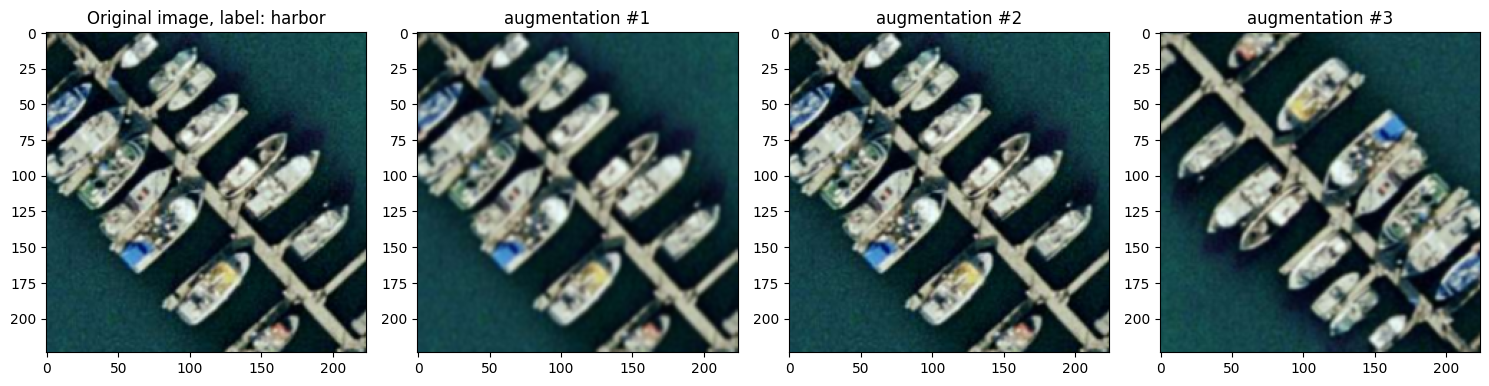

In [ ]:
def denormalize(image_tensor, mean, std):
    # Denormalize the image
    denorm_img = image_tensor * std[:, None, None] + mean[:, None, None]
    # Clip values to be between 0 and 1
    denorm_img = denorm_img.clip(0, 1)
    return denorm_img

def display(pipeline):
  # Test augmentation
  ix_to_augment = 5   # sample image to augment
  img_to_augment = original_train_images[ix_to_augment]
  lbl_to_augment = original_train_labels[ix_to_augment]

  # number of augmentations
  num_augmentations = 3
  augmented_images, augmented_labels = augment_images(pipeline, [img_to_augment], [lbl_to_augment], num_augmentations)
  f, axes = plt.subplots(1,num_augmentations+1, figsize=(15,4))

  # Visualize original image
  axes[0].imshow(denormalize(img_to_augment, mean, std).numpy().transpose((1, 2, 0)))   # Denormalize and transpose the tensor to [height, width, channels]
  axes[0].set_title(f"Original image, label: {label_mapping[lbl_to_augment]}")

  # Visualize augmentations
  for ix, (ax, tensor) in enumerate(zip(axes[1:], augmented_images)):
    # Denormalize and transpose the tensor to [height, width, channels]
    image = denormalize(tensor, mean, std).numpy().transpose((1, 2, 0))
    # Plotting
    ax.imshow(image)
    ax.set_title(f"augmentation #{ix+1}")

  f.tight_layout()
  f.show()

display(transformation_pipeline)

### Augment the Training Dataset

In [ ]:
# Choose whether to augment or not your dataset
do_augmentation = True

if do_augmentation:
  # Augment the train_images dataset
  num_augmentations = 3
  # Stack the original train images with the augmented ones
  augmented_train_images, augmented_train_labels = augment_images(transformation_pipeline, original_train_images, original_train_labels, num_augmentations)
  augmented_train_images = torch.cat((original_train_images, augmented_train_images), dim=0)
  augmented_train_labels = torch.cat((torch.Tensor(original_train_labels), augmented_train_labels), dim=0).to(torch.long)
else:
  # ... or use the original train images
  augmented_train_images = original_train_images
  augmented_train_labels = torch.tensor(original_train_labels)

### Load and normalize Validation and Test Dataset

In [ ]:
# Transformation with normalization for validation and test dataset
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Create TensorDatasets
augmented_train_dataset = TensorDataset(augmented_train_images, augmented_train_labels)

# Create DataLoaders
augmented_train_loader = DataLoader(augmented_train_dataset, batch_size=64, shuffle=True)

In [ ]:
print(f'Original data set has {len(train_dataset)} samples, augmented data set has {len(augmented_train_dataset)} samples.')

Original data set has 350 samples, augmented data set has 1400 samples.


In [ ]:
model2 = EvenDeeperCNN(num_classes=num_classes).to(device)
metrics2 = train(model2, augmented_train_loader, lr=0.0005, path='/best_model2.pth', num_epochs=10)
# Load the best model after training is complete
model2.load_state_dict(torch.load('/best_model2.pth'))
print("Loaded best model from:", '/best_model2.pth')

Epoch 1: Improved validation accuracy to 6.67%. Model saved.
Epoch 1/10 Train Loss: 3.0098, Validation Loss: 3.0777, Accuracy: 6.67%
Epoch 2: Improved validation accuracy to 9.33%. Model saved.
Epoch 2/10 Train Loss: 2.6940, Validation Loss: 3.0746, Accuracy: 9.33%
Epoch 3: Improved validation accuracy to 16.00%. Model saved.
Epoch 3/10 Train Loss: 2.3335, Validation Loss: 2.7042, Accuracy: 16.00%
Epoch 4: Improved validation accuracy to 17.33%. Model saved.
Epoch 4/10 Train Loss: 2.0763, Validation Loss: 2.3438, Accuracy: 17.33%
Epoch 5: Improved validation accuracy to 21.33%. Model saved.
Epoch 5/10 Train Loss: 1.7547, Validation Loss: 3.1207, Accuracy: 21.33%
Epoch 6: Improved validation accuracy to 33.33%. Model saved.
Epoch 6/10 Train Loss: 1.2870, Validation Loss: 3.7864, Accuracy: 33.33%
Epoch 7: Improved validation accuracy to 37.33%. Model saved.
Epoch 7/10 Train Loss: 0.7781, Validation Loss: 3.2859, Accuracy: 37.33%
Epoch 8: Improved validation accuracy to 44.00%. Model save

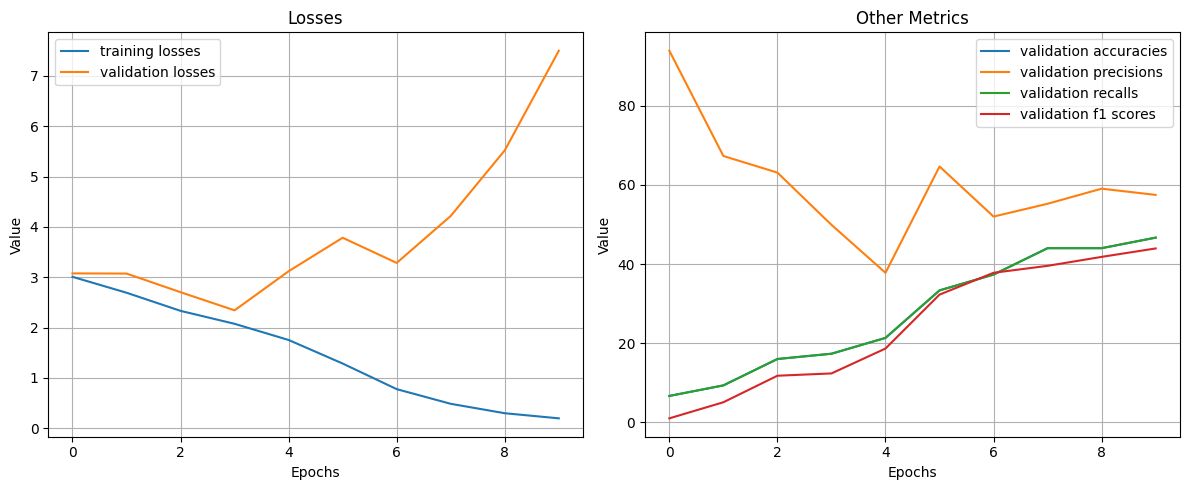

Accuracy: 32.00%, Precision: 48.08%, Recall: 32.00%, F1 Score: 26.68%


In [ ]:
visualize(metrics2)
test(model2, test_loader)

We were able to achieve an increase of over 10-20% across most metrics.

## More Complex Data Augmentation Pipeline
We will now add some rotation and perspective distortion, along with center cropping to make the pipeline more complex and see if this can further increase the performance of our model.

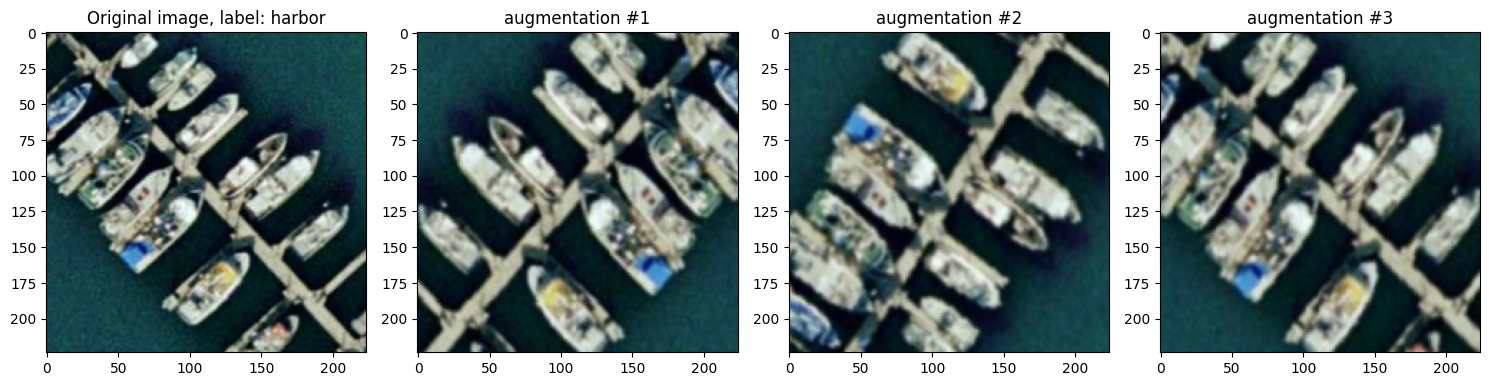

In [ ]:
better_augmentation_pipeline = transforms.Compose([
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5), # random perspective to distort image
    transforms.RandomRotation(degrees=(-10,10)), # rotates image
    transforms.RandomHorizontalFlip(p=0.5), # flip some horizontally
    transforms.RandomVerticalFlip(p=0.5), # flip some vertically
    transforms.GaussianBlur(kernel_size=(3, 9), sigma=(0.1, 1)), # blur some amount
    transforms.CenterCrop(size=(180,200)), # crop to center to remove random background
    transforms.Resize((224, 224), antialias=True)
])

display(better_augmentation_pipeline)

In [ ]:
num_augmentations = 3
# Stack the original train images with the augmented ones
better_augmented_train_images, better_augmented_train_labels = augment_images(better_augmentation_pipeline, original_train_images, original_train_labels, num_augmentations)
better_augmented_train_images = torch.cat((original_train_images, better_augmented_train_images), dim=0)
better_augmented_train_labels = torch.cat((torch.Tensor(original_train_labels), better_augmented_train_labels), dim=0).to(torch.long)

In [ ]:
better_augmented_train_dataset = TensorDataset(better_augmented_train_images, better_augmented_train_labels)

better_augmented_train_loader = DataLoader(better_augmented_train_dataset, batch_size=64, shuffle=True)

In [ ]:
print(f'Original data set has {len(train_dataset)} samples, augmented data set has {len(better_augmented_train_dataset)} samples.')

Original data set has 350 samples, augmented data set has 1400 samples.


In [ ]:
model3 = EvenDeeperCNN(num_classes=num_classes).to(device)
metrics3 = train(model3, better_augmented_train_loader, lr=0.0005, path='/best_model3.pth', num_epochs=10)
# Load the best model after training is complete
model3.load_state_dict(torch.load('/best_model3.pth'))
print("Loaded best model from:", '/best_model3.pth')

Epoch 1: Improved validation accuracy to 4.00%. Model saved.
Epoch 1/10 Train Loss: 3.0395, Validation Loss: 3.1769, Accuracy: 4.00%
Epoch 2/10 Train Loss: 3.0261, Validation Loss: 3.1041, Accuracy: 2.67%
Epoch 3: Improved validation accuracy to 13.33%. Model saved.
Epoch 3/10 Train Loss: 2.9453, Validation Loss: 3.0545, Accuracy: 13.33%
Epoch 4: Improved validation accuracy to 21.33%. Model saved.
Epoch 4/10 Train Loss: 2.6299, Validation Loss: 2.7860, Accuracy: 21.33%
Epoch 5: Improved validation accuracy to 26.67%. Model saved.
Epoch 5/10 Train Loss: 2.2209, Validation Loss: 2.3208, Accuracy: 26.67%
Epoch 6: Improved validation accuracy to 30.67%. Model saved.
Epoch 6/10 Train Loss: 1.9497, Validation Loss: 2.1025, Accuracy: 30.67%
Epoch 7: Improved validation accuracy to 32.00%. Model saved.
Epoch 7/10 Train Loss: 1.6918, Validation Loss: 2.1036, Accuracy: 32.00%
Epoch 8: Improved validation accuracy to 33.33%. Model saved.
Epoch 8/10 Train Loss: 1.5003, Validation Loss: 2.0390, Ac

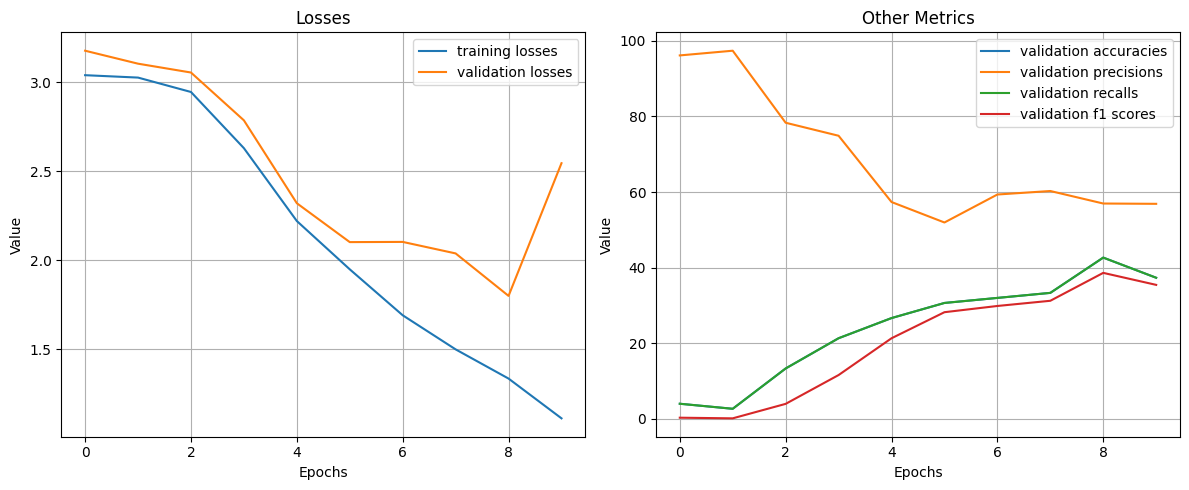

Accuracy: 32.00%, Precision: 44.19%, Recall: 32.00%, F1 Score: 29.77%


In [ ]:
visualize(metrics3)
test(model3, test_loader)

We were able to get another increase of around 2% with just these small changes.

## Scaling it Up to the Full Data Set
Now we scale it up to the full model, and see how the model compares without data augmentation (same as part one) and with data augmentation (which we hope improves performance).

In [ ]:
# Loading the entire data set
df_full = pd.read_csv('labels.csv')

# Get image file paths and labels
image_paths = df_full['image'].values
labels = df_full['label'].values
num_classes = 21 # We specify the max number of classes in the dataset, regardless of the initial subsampling
print(f'Loaded {len(image_paths)} images, with {num_classes} different classes.')

# Load the mapping between integer labels and class names
label_mapping = {}
with open('label_mapping.txt', 'r') as file:
    for line in file:
        value, key = line.strip().split(': ')
        label_mapping[int(key)] = value

Loaded 2100 images, with 21 different classes.


In [ ]:
train_paths, test_paths, original_train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.30, random_state=42)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    test_paths, test_labels, test_size=0.5, random_state=42)

In [ ]:
# Basic image transformations to load the training dataset
basic_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# mean/std calculation
original_train_images = load_images(train_paths, basic_transform)
mean, std = calculate_mean_std(original_train_images)
normalize_transform = transforms.Normalize(mean=mean, std=std)
original_train_images = torch.stack([normalize_transform(image) for image in original_train_images])

# Transformation with normalization for validation and test dataset
transform = transforms.Compose([
    transforms.Resize((224, 224), antialias=True),        # 224x224 is a common "historical" format for benchmarking CNNs
    transforms.ToTensor(),
    transforms.Normalize(mean=mean, std=std)
])

# Load and normalize the validation and test datasets
val_images = load_images(val_paths, transform)
test_images = load_images(test_paths, transform)

# Convert labels to tensors
train_labels = torch.tensor(original_train_labels)
val_labels = torch.tensor(val_labels)
test_labels = torch.tensor(test_labels)

# Create TensorDatasets
train_dataset = TensorDataset(original_train_images, train_labels)
val_dataset = TensorDataset(val_images, val_labels)
test_dataset = TensorDataset(test_images, test_labels)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

Loading images: 100%|██████████| 315/315 [00:54<00:00,  5.77it/s]


In [ ]:
full_model = EvenDeeperCNN(num_classes=num_classes).to(device)
metrics4 = train(full_model, train_loader, lr=0.00005, path='/best_model4.pth', num_epochs=10)
# Load the best model after training is complete
full_model.load_state_dict(torch.load('/best_model4.pth'))
print("Loaded best model from:", '/best_model4.pth')

Epoch 1: Improved validation accuracy to 2.54%. Model saved.
Epoch 1/10 Train Loss: 3.0454, Validation Loss: 3.0466, Accuracy: 2.54%
Epoch 2: Improved validation accuracy to 7.30%. Model saved.
Epoch 2/10 Train Loss: 3.0317, Validation Loss: 2.9594, Accuracy: 7.30%
Epoch 3: Improved validation accuracy to 14.92%. Model saved.
Epoch 3/10 Train Loss: 2.8097, Validation Loss: 2.6116, Accuracy: 14.92%
Epoch 4/10 Train Loss: 2.5386, Validation Loss: 2.6234, Accuracy: 12.06%
Epoch 5: Improved validation accuracy to 18.41%. Model saved.
Epoch 5/10 Train Loss: 2.3858, Validation Loss: 2.4987, Accuracy: 18.41%
Epoch 6: Improved validation accuracy to 25.40%. Model saved.
Epoch 6/10 Train Loss: 2.2041, Validation Loss: 2.3185, Accuracy: 25.40%
Epoch 7: Improved validation accuracy to 32.70%. Model saved.
Epoch 7/10 Train Loss: 2.0185, Validation Loss: 2.1110, Accuracy: 32.70%
Epoch 8: Improved validation accuracy to 33.33%. Model saved.
Epoch 8/10 Train Loss: 1.8149, Validation Loss: 2.0138, Acc

In [ ]:
visualize(metrics4)

This was the standard model from part 1, nothing new here.

## Full Dataset with Complex Data Augmentation Pipeline
For the final experiment, we run the full data set with data augmentation. We can directly compare this to the model in part 1 (reproduced above) and see the advantage provided by data augmentation.

Due to RAM restrictions, the number of augmentations had to be lowered from 3 to 2 so that this notebook can be ran with ease.

In [ ]:
num_augmentations = 2
# Stack the original train images with the augmented ones
better_augmented_train_images, better_augmented_train_labels = augment_images(better_augmentation_pipeline, original_train_images, original_train_labels, num_augmentations)
better_augmented_train_images = torch.cat((original_train_images, better_augmented_train_images), dim=0)
better_augmented_train_labels = torch.cat((torch.Tensor(original_train_labels), better_augmented_train_labels), dim=0).to(torch.long)

better_augmented_train_dataset = TensorDataset(better_augmented_train_images, better_augmented_train_labels)
better_augmented_train_loader = DataLoader(better_augmented_train_dataset, batch_size=64, shuffle=True)

In [ ]:
print(f'Original data set has {len(train_dataset)} samples, augmented data set has {len(better_augmented_train_dataset)} samples.')

Original data set has 1470 samples, augmented data set has 4410 samples.


In [ ]:
full_model2 = EvenDeeperCNN(num_classes=num_classes).to(device)
metrics5 = train(full_model2, better_augmented_train_loader, lr=0.00005, path='/best_model5.pth', num_epochs=10)
# Load the best model after training is complete
full_model2.load_state_dict(torch.load('/best_model5.pth'))
print("Loaded best model from:", '/best_model5.pth')

Epoch 1: Improved validation accuracy to 10.48%. Model saved.
Epoch 1/10 Train Loss: 2.9708, Validation Loss: 2.8832, Accuracy: 10.48%
Epoch 2: Improved validation accuracy to 28.57%. Model saved.
Epoch 2/10 Train Loss: 2.5574, Validation Loss: 2.2794, Accuracy: 28.57%
Epoch 3: Improved validation accuracy to 42.86%. Model saved.
Epoch 3/10 Train Loss: 2.0236, Validation Loss: 1.7981, Accuracy: 42.86%
Epoch 4: Improved validation accuracy to 51.75%. Model saved.
Epoch 4/10 Train Loss: 1.6634, Validation Loss: 1.5116, Accuracy: 51.75%
Epoch 5: Improved validation accuracy to 54.60%. Model saved.
Epoch 5/10 Train Loss: 1.3792, Validation Loss: 1.4523, Accuracy: 54.60%
Epoch 6: Improved validation accuracy to 60.00%. Model saved.
Epoch 6/10 Train Loss: 1.1651, Validation Loss: 1.3693, Accuracy: 60.00%
Epoch 7/10 Train Loss: 0.9965, Validation Loss: 1.4039, Accuracy: 58.73%
Epoch 8/10 Train Loss: 0.8440, Validation Loss: 1.5378, Accuracy: 53.97%
Epoch 9/10 Train Loss: 0.7093, Validation Lo

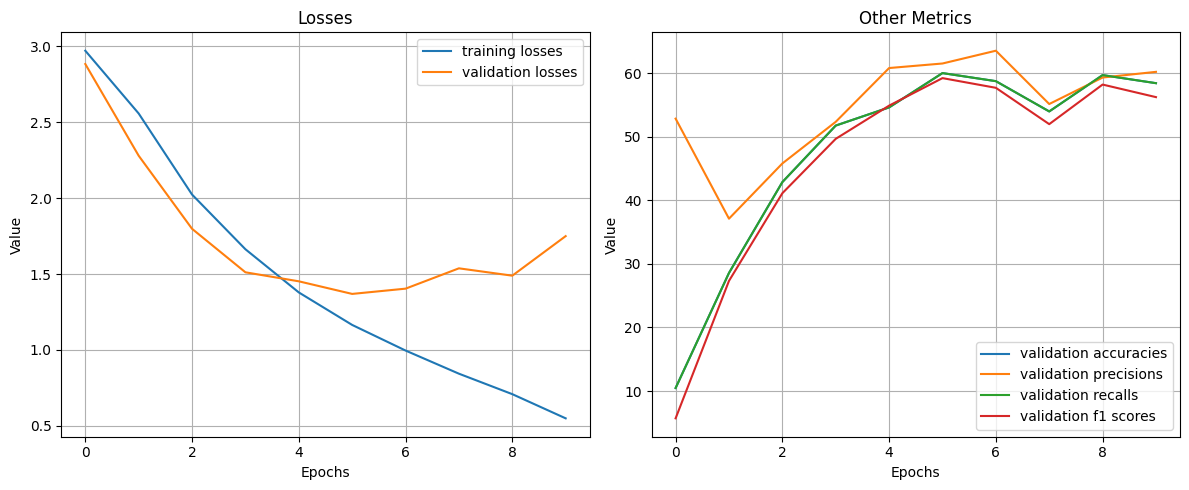

In [ ]:
visualize(metrics5)

# Evaluating the Models
We can now evaluate both models (no data augmentation and with complex data augmentation pipeline) on the test set, and compare the final results. This has been provided in a barchart.

Feel free to call this method on any of the other previous models (e.g. smaller data set in the beginning of the notebook) to compare them too.

In [ ]:
def test_compare_models(model1, model2, test_loader):
    model1.eval()
    test_loss1 = 0.0
    correct1 = 0
    total1 = 0
    true_labels1 = []
    predicted_labels1 = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model1(images)
            loss = criterion(outputs, labels)
            test_loss1 += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            true_labels1.extend(labels.cpu().numpy())
            predicted_labels1.extend(predicted.cpu().numpy())

    model2.eval()
    test_loss2 = 0.0
    correct2 = 0
    total2 = 0
    true_labels2 = []
    predicted_labels2 = []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model2(images)
            loss = criterion(outputs, labels)
            test_loss2 += loss.item()
            _, predicted = torch.max(outputs.data, 1)

            true_labels2.extend(labels.cpu().numpy())
            predicted_labels2.extend(predicted.cpu().numpy())

    # Calculate metrics
    accuracy1 = 100*accuracy_score(true_labels1, predicted_labels1)
    precision1 = 100*precision_score(true_labels1, predicted_labels1, average='weighted', zero_division=1)
    recall1 = 100*recall_score(true_labels1, predicted_labels1, average='weighted', zero_division=1)
    f11 = 100*f1_score(true_labels1, predicted_labels1, average='weighted')

    accuracy2 = 100*accuracy_score(true_labels2, predicted_labels2)
    precision2 = 100*precision_score(true_labels2, predicted_labels2, average='weighted', zero_division=1)
    recall2 = 100*recall_score(true_labels2, predicted_labels2, average='weighted', zero_division=1)
    f12 = 100*f1_score(true_labels2, predicted_labels2, average='weighted')

    # Calculate gain in metrics for model 2
    accuracy_gain = accuracy2 - accuracy1
    precision_gain = precision2 - precision1
    recall_gain = recall2 - recall1
    f1_gain = f12 - f11

    # Create bar chart comparing metric gains
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    gains = [accuracy_gain, precision_gain, recall_gain, f1_gain]
    values1 = [accuracy1, precision1, recall1, f11]
    values2 = [accuracy2, precision2, recall2, f12]

    bar_width = 0.35
    x = np.arange(len(metrics))

    plt.figure(figsize=(8, 6))
    plt.bar(x - bar_width/2, values1, bar_width, label='Standard Dataset', color='blue')
    plt.bar(x + bar_width/2, values2, bar_width, label='Augmented Dataset', color='green')

    plt.xlabel('Metrics')
    plt.ylabel('Value (%)')
    plt.title('Gain through Data Augmentation')

    for i, diff in enumerate(gains):
        plt.text(i - 0.1, max(values1[i], values2[i]) + 1, f'Diff: {diff:.2f}%', color='black')

    plt.xticks(x, metrics)
    plt.legend()
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

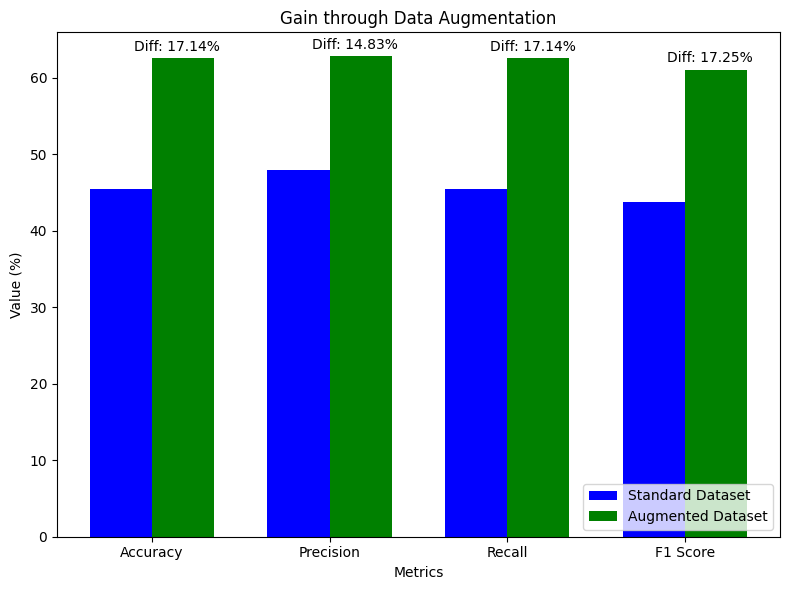

In [ ]:
test_compare_models(full_model, full_model2, test_loader)